In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)

In [20]:
df = pd.read_csv('00005.csv')
print(df.columns.tolist())
print(df.head())

['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load', 'Time']
   Voltage_measured  Current_measured  Temperature_measured  Current_load  \
0          4.186636         -0.001666              5.454957        0.0002   
1          4.186626         -0.002432              5.485011        0.0002   
2          4.001180         -0.995300              5.510369        1.0000   
3          3.982544         -0.994923              5.581233        1.0000   
4          3.968436         -0.995817              5.640744        1.0000   

   Voltage_load    Time  
0         0.000   0.000  
1         4.203   9.297  
2         3.431  23.265  
3         3.411  36.437  
4         3.398  49.609  


# Load NASA Li-ion Battery Data

Real discharge cycle data from NASA Ames Prognostics Center of Excellence.
Battery 00005 — 18650 Li-ion cell cycled to end of life.
Source: https://kaggle.com/datasets/patrickfleith/nasa-battery-dataset

`data = np.column_stack([voltage, current, temperature])` This takes separate 1D arrays and stacks them as columns into a 2D matrix. Before this line you have three separate 1D arrays each of shape `(100,)`. After this line you have one unified matrix of shape `(100, 3)` — 100 rows, 3 columns.

In [21]:
# Load real NASA Li-ion battery discharge data
df = pd.read_csv('00005.csv')

# Extract the three sensor columns
voltage     = df['Voltage_measured'].values
current     = np.abs(df['Current_measured'].values)   # negative values — abs() fixes that
temperature = df['Temperature_measured'].values

# Stack into one matrix
data = np.column_stack([voltage, current, temperature])

print("Data source: NASA Li-ion Battery Aging Dataset")
print("Data shape:", data.shape)
print("First 5 readings:\n", data[:5].round(3))

Data source: NASA Li-ion Battery Aging Dataset
Data shape: (429, 3)
First 5 readings:
 [[4.187e+00 2.000e-03 5.455e+00]
 [4.187e+00 2.000e-03 5.485e+00]
 [4.001e+00 9.950e-01 5.510e+00]
 [3.983e+00 9.950e-01 5.581e+00]
 [3.968e+00 9.960e-01 5.641e+00]]


# Pattern 1: Mask outliers (boolean masking)

In [22]:
# Physical limits based on actual NASA dataset ranges
voltage_ok     = (data[:, 0] > 2.4)  & (data[:, 0] < 4.3)
current_ok     = (data[:, 1] > 0.0)  & (data[:, 1] < 1.5)
temperature_ok = (data[:, 2] > 4.0)  & (data[:, 2] < 15.0)

# Combined mask — reading is valid only if ALL sensors are within range. Size (100,)
valid_mask = voltage_ok & current_ok & temperature_ok

clean_data = data[valid_mask]

print(f"Original readings:  {len(data)}")
print(f"After cleaning:     {len(clean_data)}")
print(f"Faulty readings removed: {len(data) - len(clean_data)}")

Original readings:  429
After cleaning:     429
Faulty readings removed: 0


# Pattern 3 & 2: Statistics using vectorisation and axis

The `:.3f` formats the number to 3 decimal places.
`enumerate` wraps the list and automatically produces a counter alongside each item. Every iteration it gives you two things at once — the current index and the current value:
`col = clean_data[:, i]` grabs all the rows in the column i. So when i = 0, it grabs all the Voltage values, when i = 1, it grabs all the Current values and so on.

In [23]:
sensor_names = ['Voltage (V)', 'Current (A)', 'Temperature (C)']

print("=== Sensor Statistics (clean data) ===\n")
for i, name in enumerate(sensor_names):
    col = clean_data[:, i]
    print(f"{name}")
    print(f"  Mean:    {col.mean():.3f}")
    print(f"  Std dev: {col.std():.3f}")
    print(f"  Min:     {col.min():.3f}")
    print(f"  Max:     {col.max():.3f}\n")

=== Sensor Statistics (clean data) ===

Voltage (V)
  Mean:    3.477
  Std dev: 0.272
  Min:     2.478
  Max:     4.187

Current (A)
  Mean:    0.984
  Std dev: 0.107
  Min:     0.002
  Max:     0.998

Temperature (C)
  Mean:    8.211
  Std dev: 1.239
  Min:     5.455
  Max:     11.315



# Pattern 2: Normalise using broadcasting

The formula `(x - mean) / std` is Z-score standardisation, the full normalisation, not just mean centering. After this every column has mean ≈ 0 and standard deviation ≈ 1, making all three sensors directly comparable regardless of their original units. 
`.round(n)`
Rounds every element to n decimal places. Used to verify the normalisation worked correctly, if means are very close to 0 and stds very close to 1, the maths is right.

In [24]:
# Z-score normalisation — subtract mean, divide by std
# axis=0 so we normalise each sensor (column) independently
means = clean_data.mean(axis=0, keepdims=True)   # shape (1, 3)
stds  = clean_data.std(axis=0, keepdims=True)    # shape (1, 3)

normalised = (clean_data - means) / stds

print("After normalisation:")
print(f"  Means (should be ~0): {normalised.mean(axis=0).round(4)}")
print(f"  Stds  (should be ~1): {normalised.std(axis=0).round(4)}")

After normalisation:
  Means (should be ~0): [ 0. -0. -0.]
  Stds  (should be ~1): [1. 1. 1.]


# Pattern 4: Find most anomalous readings

`anomaly_scores = np.sum(normalised**2, axis=1)` This line combines three patterns at once:
- **Pattern 3 (vectorisation)** — normalised**2 squares every element in the entire matrix at once, no loop.
- **Pattern 5 (axis parameter)** — axis=1 sums across columns for each row, giving one score per reading. Axis=1 collapses columns, here it collapses the 3 sensor columns into a single number per row.
- **Pattern 2 (broadcasting)** — the **2 operation broadcasts across the entire matrix shape.

In [25]:
# Anomaly score — how far each reading is from normal (across all sensors)
# Sum of squared normalised values per reading
anomaly_scores = np.sum(normalised**2, axis=1)   # shape (100,) one score per reading

# Top 5 most anomalous readings
top5 = np.argsort(anomaly_scores)[::-1][:5]

print("Top 5 most anomalous readings:")
print(f"{'Index':<8} {'Voltage':>10} {'Current':>10} {'Temp':>10} {'Score':>10}")
print("-" * 50)
for idx in top5:
    v, c, t = clean_data[idx]
    print(f"{idx:<8} {v:>10.3f} {c:>10.3f} {t:>10.3f} {anomaly_scores[idx]:>10.3f}")

Top 5 most anomalous readings:
Index       Voltage    Current       Temp      Score
--------------------------------------------------
0             4.187      0.002      5.455     96.682
1             4.187      0.002      5.485     96.442
426           2.973      0.004     10.904     92.678
427           3.080      0.003     10.869     91.494
428           3.128      0.002     10.805     90.973


# Visualise with plots

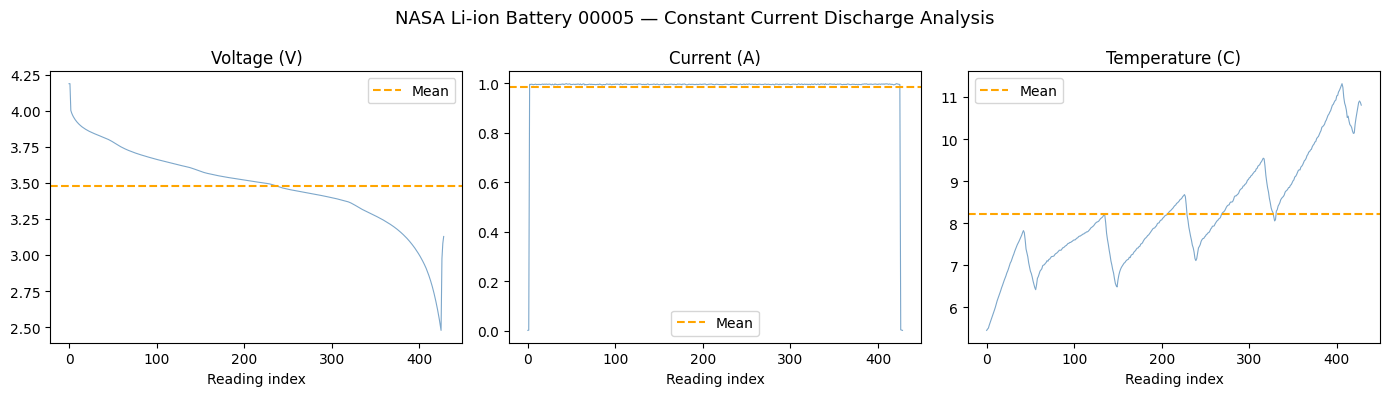

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, (ax, name) in enumerate(zip(axes, sensor_names)):
    ax.plot(clean_data[:, i], color='steelblue', linewidth=0.8, alpha=0.7)
    ax.axhline(means[0, i], color='orange', linestyle='--', label='Mean')
    ax.set_title(name)
    ax.set_xlabel('Reading index')
    ax.legend()

plt.suptitle('NASA Li-ion Battery 00005 — Constant Current Discharge Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('sensor_analysis.png', dpi=150)
plt.show()